In [1]:
import pandas as pd
import numpy as np
import time
import warnings
from typing import List, Dict, Any, Tuple
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
import os
from tqdm.auto import tqdm

# ML/Search libraries
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, CrossEncoder
import faiss
from sklearn.metrics.pairwise import cosine_similarity

# Configure visualization
plt.style.use('default')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

def measure_time(func):
    """Decorator to measure execution time of functions."""
    def wrapper(*args, **kwargs):
        start_time = time.time()
        result = func(*args, **kwargs)
        end_time = time.time()
        print(f"{func.__name__} executed in {end_time - start_time:.4f} seconds")
        return result
    return wrapper

def create_listing_text(row: pd.Series) -> str:
    """Create comprehensive text description from Airbnb listing data."""
    text = f"{row.get('listing_name', 'Listing')} is a {row.get('accommodation_type', 'accommodation')} "
    text += f"for {row.get('max_guests', 'N/A')} guests. "
    text += f"It costs ${row.get('price', 0):.0f} per night with a rating of {row.get('rating', 0):.2f} "
    text += f"and {row.get('review_count', 0)} reviews. "
    text += f"Description: {row.get('description', 'No description available')} "

    # Handle amenities
    amenities = row.get('amenities_list', [])
    if isinstance(amenities, list) and amenities:
        text += f"Amenities include: {', '.join(amenities)}"
    elif isinstance(amenities, str):
        text += f"Amenities: {amenities}"
    else:
        text += "Amenities: Not specified"

    return text

def create_sample_airbnb_data(n_samples: int = 1500) -> pd.DataFrame:
    """Generate realistic Stockholm Airbnb-like sample data for demo."""
    np.random.seed(42)  # For reproducible results

    # Realistic listing names
    sample_names = [
        "Cozy Stockholm Apartment", "Modern City Center Flat", "Luxury Downtown Suite",
        "Budget-Friendly Room", "Spacious Family Home", "Stylish Studio",
        "Traditional Swedish House", "Waterfront Apartment", "Historic District Room",
        "Minimalist Loft", "Garden View Studio", "Executive Suite", "Artistic Retreat",
        "Scandinavian Design Flat", "Central Station Apartment", "Quiet Residential Room",
        "Rooftop Penthouse", "Vintage Charm Apartment", "Business Traveler Suite",
        "Family-Friendly Home", "Designer Apartment", "Cozy Attic Room"
    ]

    # Realistic descriptions
    sample_descriptions = [
        "Beautiful apartment in the heart of Stockholm with modern amenities and great transport links",
        "Modern and clean space perfect for business travelers and tourists alike",
        "Luxury accommodation with stunning city views and premium furnishings throughout",
        "Affordable option for budget travelers, clean and comfortable with basic amenities",
        "Perfect for families visiting Stockholm, spacious with multiple bedrooms and family amenities",
        "Stylish studio apartment with contemporary design and efficient use of space",
        "Traditional Swedish architecture with modern comforts, offering unique cultural experience",
        "Beautiful waterfront location with amazing views and peaceful atmosphere",
        "Located in historic district, walking distance to major attractions and restaurants",
        "Minimalist design with high-end finishes, perfect for those who appreciate clean aesthetics",
        "Bright space with garden views, quiet and relaxing environment",
        "Professional accommodation with business amenities and fast internet",
        "Creative space with artistic touches, inspiring environment for creative minds",
        "Authentic Scandinavian design with quality furniture and attention to detail"
    ]

    # Realistic amenity combinations
    amenities_options = [
        ['Wifi', 'Kitchen', 'TV', 'Air conditioning'],
        ['Wifi', 'Kitchen', 'Washer', 'Heating'],
        ['Wifi', 'Kitchen', 'TV', 'Air conditioning', 'Dishwasher', 'Balcony'],
        ['Wifi', 'Heating', 'Essentials'],
        ['Wifi', 'Kitchen', 'TV', 'Washer', 'Family/kid friendly'],
        ['Wifi', 'Kitchen', 'TV', 'Air conditioning', 'Gym', 'Pool'],
        ['Wifi', 'Kitchen', 'Laptop friendly workspace', 'Self check-in'],
        ['Wifi', 'Kitchen', 'TV', 'Hair dryer', 'Iron', 'Hangers']
    ]

    # Generate the dataset
    df = pd.DataFrame({
        'listing_id': range(1, n_samples + 1),
        'listing_name': np.random.choice(sample_names, n_samples),
        'accommodation_type': np.random.choice(
            ['Entire place', 'Private room', 'Shared room'],
            n_samples,
            p=[0.65, 0.30, 0.05]  # More realistic distribution
        ),
        'max_guests': np.random.choice(
            [1, 2, 3, 4, 5, 6, 8],
            n_samples,
            p=[0.1, 0.35, 0.20, 0.20, 0.10, 0.04, 0.01]
        ),
        'price': np.clip(
            np.random.lognormal(5.5, 0.8, n_samples),
            30, 3000
        ).round(2),
        'rating': np.round(
            np.random.beta(8.5, 1.5, n_samples) * 5,  # Skewed toward higher ratings
            2
        ),
        'review_count': np.random.poisson(65, n_samples),  # Average ~65 reviews
        'description': np.random.choice(sample_descriptions, n_samples),
        'amenities_list': [
            list(amenities_options[np.random.randint(0, len(amenities_options))])
            for _ in range(n_samples)
        ]
    })

    # Create comprehensive text descriptions
    df['text_description'] = df.apply(create_listing_text, axis=1)

    return df

def display_search_results(results: pd.DataFrame, query: str, method: str, top_k: int = 5):
    """Display search results in a nice format."""
    print(f"\n🔍 {method} Results for: '{query}'")
    print("=" * 70)

    for i, (_, row) in enumerate(results.head(top_k).iterrows(), 1):
        print(f"\n{i}. {row['listing_name']}")
        print(f"   💰 ${row['price']:.0f}/night | ⭐ {row['rating']:.2f} ({row['review_count']} reviews)")
        print(f"   🏠 {row['accommodation_type']} for {row['max_guests']} guests")
        if 'score' in row.index:
            print(f"   📊 Score: {row['score']:.4f}")
        elif 'similarity_score' in row.index:
            print(f"   📊 Similarity: {row['similarity_score']:.4f}")
        print(f"   📝 {row['description'][:80]}...")
        print("-" * 50)

# Generate sample Stockholm Airbnb data for demonstration
print("📁 Creating Stockholm Airbnb sample dataset...")
df = create_sample_airbnb_data(n_samples=1500)

# Alternative: Upload your own CSV file
# Uncomment the following lines to upload your own data:
# from google.colab import files
# print("📤 Upload your CSV file:")
# uploaded = files.upload()
# if uploaded:
#     filename = list(uploaded.keys())[0]
#     df = pd.read_csv(filename)
#     if 'text_description' not in df.columns:
#         df['text_description'] = df.apply(create_listing_text, axis=1)
#     print(f"✅ Custom data loaded: {len(df)} listings")

print(f"\n📋 Dataset Summary:")
print(f"- Total listings: {len(df):,}")
print(f"- Price range: ${df['price'].min():.0f} - ${df['price'].max():.0f}")
print(f"- Rating range: {df['rating'].min():.2f} - {df['rating'].max():.2f}")
print(f"- Average reviews per listing: {df['review_count'].mean():.0f}")
print(f"- Accommodation types: {df['accommodation_type'].value_counts().to_dict()}")

# Display sample data
print(f"\n🔍 Sample listings:")
display(df[['listing_name', 'accommodation_type', 'price', 'rating', 'max_guests', 'review_count']].head())

print(f"\n📝 Sample text description:")
print(f"'{df['text_description'].iloc[0][:200]}...'")

📁 Creating Stockholm Airbnb sample dataset...

📋 Dataset Summary:
- Total listings: 1,500
- Price range: $30 - $3000
- Rating range: 1.74 - 5.00
- Average reviews per listing: 65
- Accommodation types: {'Entire place': 965, 'Private room': 454, 'Shared room': 81}

🔍 Sample listings:


,listing_name,accommodation_type,price,rating,max_guests,review_count
0,Traditional Swedish House,Private room,396.47,4.64,2,73
1,Family-Friendly Home,Private room,310.61,4.53,5,61
2,Central Station Apartment,Private room,407.86,4.08,2,70
3,Garden View Studio,Entire place,570.49,3.75,6,48
4,Waterfront Apartment,Entire place,328.36,4.31,1,60



📝 Sample text description:
'Traditional Swedish House is a Private room for 2 guests. It costs $396 per night with a rating of 4.64 and 73 reviews. Description: Bright space with garden views, quiet and relaxing environment Amen...'


In [2]:
class BM25Search:
    """BM25 keyword-based search implementation."""

    def __init__(self, df: pd.DataFrame):
        self.df = df
        self.corpus = df['text_description'].tolist()
        self.tokenized_corpus = [doc.lower().split() for doc in self.corpus]
        print("🔄 Building BM25 index...")
        self.bm25 = BM25Okapi(self.tokenized_corpus)
        self.meta_data = {}

    @measure_time
    def search(self, query: str, top_k: int = 10) -> Tuple[pd.DataFrame, dict]:
        """Perform BM25 search."""
        start_time = time.time()
        tokenized_query = query.lower().split()
        scores = self.bm25.get_scores(tokenized_query)

        results = self.df.copy()
        results['score'] = scores
        results = results.sort_values('score', ascending=False).head(top_k)

        self.meta_data = {
            'method': 'BM25',
            'search_time': time.time() - start_time,
            'query': query,
            'top_k': top_k
        }

        return results, self.meta_data

print("✅ BM25Search class defined")

class VectorSearch:
    """Dense vector search using sentence transformers."""

    def __init__(self, df: pd.DataFrame, model_name: str = 'all-MiniLM-L12-v2'):
        self.df = df
        self.model_name = model_name
        print(f"🔄 Loading model: {model_name}")
        self.model = SentenceTransformer(model_name)

        print("🔄 Creating embeddings...")
        self.embeddings = self.model.encode(
            self.df['text_description'].tolist(),
            normalize_embeddings=True,
            show_progress_bar=True
        ).astype(np.float32)

        print("🔄 Building FAISS index...")
        self.index = self._create_faiss_index()
        self.meta_data = {}

    def _create_faiss_index(self):
        """Create FAISS index for fast similarity search."""
        vector_dimension = self.embeddings.shape[1]
        index = faiss.IndexFlatIP(vector_dimension)  # Inner product for cosine similarity
        index.add(self.embeddings)
        return index

    @measure_time
    def search(self, query: str, top_k: int = 10) -> Tuple[pd.DataFrame, dict]:
        """Perform vector similarity search."""
        start_time = time.time()

        query_embedding = self.model.encode(
            [query],
            normalize_embeddings=True
        ).astype(np.float32)

        scores, indices = self.index.search(query_embedding, top_k)

        results = self.df.iloc[indices[0]].copy()
        results['score'] = scores[0]

        self.meta_data = {
            'method': 'Vector',
            'model': self.model_name,
            'search_time': time.time() - start_time,
            'query': query,
            'top_k': top_k
        }

        return results, self.meta_data

print("✅ VectorSearch class defined")

class HybridSearch:
    """Hybrid search combining BM25 and vector search."""

    def __init__(self, df: pd.DataFrame, model_name: str = 'all-MiniLM-L12-v2'):
        self.df = df
        print("🔄 Initializing BM25 component...")
        self.bm25_search = BM25Search(df)
        print("🔄 Initializing Vector component...")
        self.vector_search = VectorSearch(df, model_name)
        self.meta_data = {}

    @measure_time
    def search(self, query: str, alpha: float = 0.4, top_k: int = 10) -> Tuple[pd.DataFrame, dict]:
        """Perform hybrid search with linear combination of scores."""
        start_time = time.time()

        # Get results from both methods
        bm25_results, _ = self.bm25_search.search(query, top_k=len(self.df))
        vector_results, _ = self.vector_search.search(query, top_k=len(self.df))

        # Normalize scores to [0,1] range
        bm25_scores = bm25_results['score'].values
        bm25_scores_norm = (bm25_scores - np.min(bm25_scores)) / (np.max(bm25_scores) - np.min(bm25_scores) + 1e-8)

        vector_scores = vector_results['score'].values
        vector_scores_norm = (vector_scores - np.min(vector_scores)) / (np.max(vector_scores) - np.min(vector_scores) + 1e-8)

        # Combine scores using linear combination
        hybrid_scores = alpha * bm25_scores_norm + (1 - alpha) * vector_scores_norm

        results = self.df.copy()
        results['score'] = hybrid_scores
        results = results.sort_values('score', ascending=False).head(top_k)

        self.meta_data = {
            'method': 'Hybrid',
            'alpha': alpha,
            'search_time': time.time() - start_time,
            'query': query,
            'top_k': top_k
        }

        return results, self.meta_data

print("✅ HybridSearch class defined")

class CrossEncoderSearch:
    """Cross-encoder reranking on top of initial retrieval."""

    def __init__(self, df: pd.DataFrame,
                 retriever_model: str = 'all-MiniLM-L12-v2',
                 cross_encoder_model: str = 'cross-encoder/ms-marco-MiniLM-L-6-v2'):
        self.df = df
        print("🔄 Initializing retriever...")
        self.vector_search = VectorSearch(df, retriever_model)
        print(f"🔄 Loading cross-encoder: {cross_encoder_model}")
        self.cross_encoder = CrossEncoder(cross_encoder_model)
        self.meta_data = {}

    @measure_time
    def search(self, query: str, top_k: int = 10, initial_k: int = 50) -> Tuple[pd.DataFrame, dict]:
        """Perform cross-encoder reranking."""
        start_time = time.time()

        # First stage: retrieve candidates
        initial_results, _ = self.vector_search.search(query, top_k=initial_k)

        # Second stage: rerank with cross-encoder
        descriptions = initial_results['text_description'].tolist()
        pairs = [(query, doc) for doc in descriptions]
        scores = self.cross_encoder.predict(pairs)

        # Rerank and return top results
        reranked_results = initial_results.copy()
        reranked_results['score'] = scores
        reranked_results = reranked_results.sort_values('score', ascending=False).head(top_k)

        self.meta_data = {
            'method': 'Cross-Encoder',
            'search_time': time.time() - start_time,
            'query': query,
            'top_k': top_k,
            'initial_k': initial_k
        }

        return reranked_results, self.meta_data

print("✅ CrossEncoderSearch class defined")

✅ BM25Search class defined
✅ VectorSearch class defined
✅ HybridSearch class defined
✅ CrossEncoderSearch class defined


In [3]:
print("🚀 Initializing search methods...")
print("This may take a few minutes on first run...\n")

# Initialize BM25
print("1️⃣ Initializing BM25...")
bm25_searcher = BM25Search(df)
print("✅ BM25 ready\n")

# Initialize Vector Search
print("2️⃣ Initializing Vector Search...")
vector_searcher = VectorSearch(df)
print("✅ Vector Search ready\n")

# Initialize Hybrid Search
print("3️⃣ Initializing Hybrid Search...")
hybrid_searcher = HybridSearch(df)
print("✅ Hybrid Search ready\n")

# Initialize Cross-Encoder
print("4️⃣ Initializing Cross-Encoder...")
cross_encoder_searcher = CrossEncoderSearch(df)
print("✅ Cross-Encoder ready\n")

🚀 Initializing search methods...
This may take a few minutes on first run...

1️⃣ Initializing BM25...
🔄 Building BM25 index...
✅ BM25 ready

2️⃣ Initializing Vector Search...
🔄 Loading model: all-MiniLM-L12-v2
🔄 Creating embeddings...


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

🔄 Building FAISS index...
✅ Vector Search ready

3️⃣ Initializing Hybrid Search...
🔄 Initializing BM25 component...
🔄 Building BM25 index...
🔄 Initializing Vector component...
🔄 Loading model: all-MiniLM-L12-v2
🔄 Creating embeddings...


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

🔄 Building FAISS index...
✅ Hybrid Search ready

4️⃣ Initializing Cross-Encoder...
🔄 Initializing retriever...
🔄 Loading model: all-MiniLM-L12-v2
🔄 Creating embeddings...


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

🔄 Building FAISS index...
🔄 Loading cross-encoder: cross-encoder/ms-marco-MiniLM-L-6-v2
✅ Cross-Encoder ready



In [4]:
# Define test queries that showcase different search scenarios
test_queries = [
    "affordable places with good reviews",
    "luxury apartment for 4 guests",
    "modern studio with kitchen and wifi",
    "family friendly accommodation near city center",
    "budget room for solo traveler",
    "spacious apartment with great amenities",
    "cozy place for couples"
]

def run_search_comparison(query: str, top_k: int = 5):
    """Run all available search methods and compare results."""
    print(f"\n🔍 Query: '{query}'")
    print("=" * 80)

    results = {}

    # BM25
    bm25_results, bm25_meta = bm25_searcher.search(query, top_k)
    results['BM25'] = (bm25_results, bm25_meta)
    print(f"✅ BM25: {bm25_meta['search_time']:.4f}s")

    # Vector Search
    vector_results, vector_meta = vector_searcher.search(query, top_k)
    results['Vector'] = (vector_results, vector_meta)
    print(f"✅ Vector: {vector_meta['search_time']:.4f}s")

    # Hybrid Search
    hybrid_results, hybrid_meta = hybrid_searcher.search(query, top_k=top_k)
    results['Hybrid'] = (hybrid_results, hybrid_meta)
    print(f"✅ Hybrid: {hybrid_meta['search_time']:.4f}s")

    # Cross-Encoder
    ce_results, ce_meta = cross_encoder_searcher.search(query, top_k)
    results['Cross-Encoder'] = (ce_results, ce_meta)
    print(f"✅ Cross-Encoder: {ce_meta['search_time']:.4f}s")

    return results

# Run benchmark on first query
sample_query = test_queries[0]
print(f"🚀 Running benchmark with query: '{sample_query}'")
sample_results = run_search_comparison(sample_query)

print("\n🎉 Benchmark complete!")

🚀 Running benchmark with query: 'affordable places with good reviews'

🔍 Query: 'affordable places with good reviews'
search executed in 0.0041 seconds
✅ BM25: 0.0041s
search executed in 0.0263 seconds
✅ Vector: 0.0263s
search executed in 0.0026 seconds
search executed in 0.0137 seconds
search executed in 0.0176 seconds
✅ Hybrid: 0.0175s
search executed in 0.0131 seconds
search executed in 0.0411 seconds
✅ Cross-Encoder: 0.0411s

🎉 Benchmark complete!


In [6]:
# Display detailed results comparison
print("📋 DETAILED RESULTS COMPARISON")
print(f"query: {sample_query}")
print("=" * 80)

for method, (results_df, meta) in sample_results.items():
    print(f"\n🔹 {method} Results (Search time: {meta['search_time']:.4f}s):")
    print("-" * 60)

    for i, (_, row) in enumerate(results_df.head(3).iterrows(), 1):
        print(f"\n  {i}. {row['listing_name']}")
        print(f"     💰 ${row['price']:.0f}/night | ⭐ {row['rating']:.2f} ({row['review_count']} reviews)")
        print(f"     🏠 {row['accommodation_type']} for {row['max_guests']} guests")
        if 'score' in row.index:
            print(f"     📊 Score: {row['score']:.4f}")
        print(f"     📝 {row['description'][:80]}...")

    print("\n" + "-" * 60)

📋 DETAILED RESULTS COMPARISON
query: affordable places with good reviews

🔹 BM25 Results (Search time: 0.0041s):
------------------------------------------------------------

  1. Designer Apartment
     💰 $276/night | ⭐ 4.83 (64 reviews)
     🏠 Entire place for 5 guests
     📊 Score: 4.6180
     📝 Affordable option for budget travelers, clean and comfortable with basic ameniti...

  2. Artistic Retreat
     💰 $129/night | ⭐ 4.32 (65 reviews)
     🏠 Private room for 2 guests
     📊 Score: 4.6180
     📝 Affordable option for budget travelers, clean and comfortable with basic ameniti...

  3. Executive Suite
     💰 $159/night | ⭐ 2.47 (75 reviews)
     🏠 Entire place for 3 guests
     📊 Score: 4.6180
     📝 Affordable option for budget travelers, clean and comfortable with basic ameniti...

------------------------------------------------------------

🔹 Vector Results (Search time: 0.0263s):
------------------------------------------------------------

  1. Budget-Friendly Room
     💰 $1

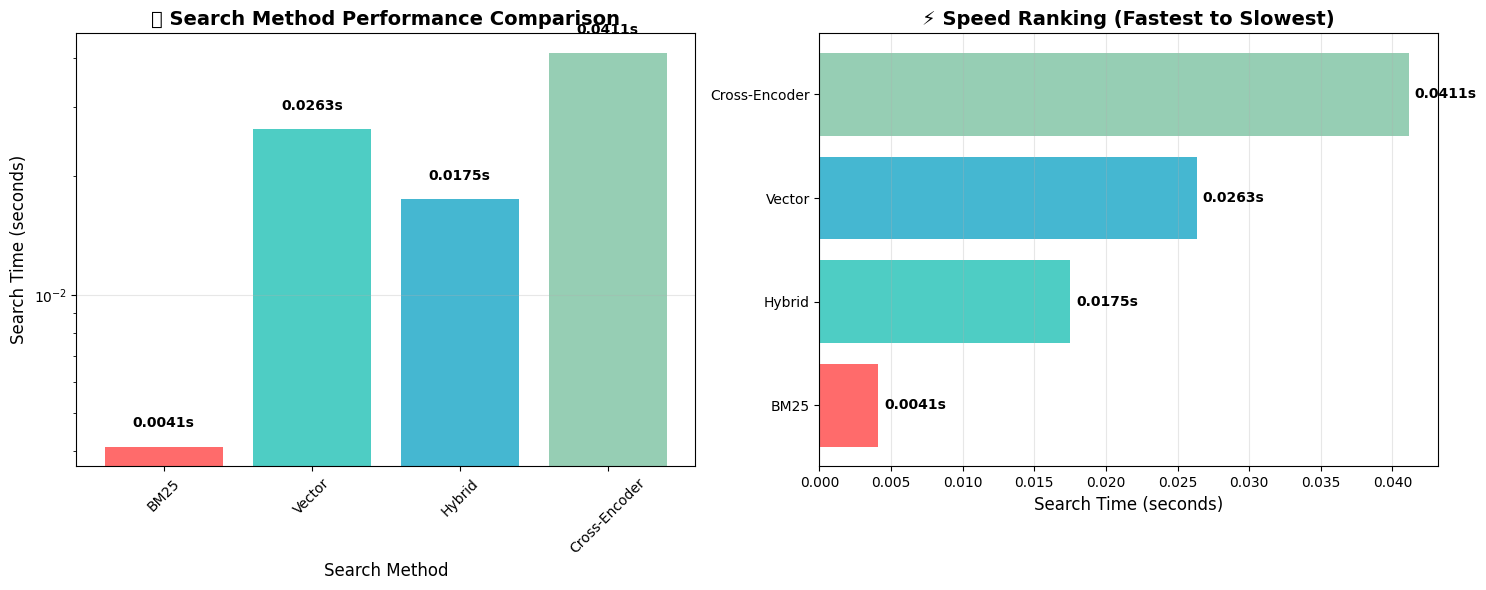


📊 PERFORMANCE SUMMARY:
🥇 1. BM25           : 0.0041s
🥈 2. Hybrid         : 0.0175s
🥉 3. Vector         : 0.0263s
📊 4. Cross-Encoder  : 0.0411s

⚡ BM25 is 10.0x faster than Cross-Encoder


In [7]:
# Create performance comparison charts
def create_performance_analysis(results_dict):
    """Create comprehensive performance analysis."""

    # Extract performance data
    methods = []
    search_times = []

    for method, (_, meta) in results_dict.items():
        methods.append(method)
        search_times.append(meta['search_time'])

    # Create performance chart
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Search time comparison
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
    bars = ax1.bar(methods, search_times, color=colors[:len(methods)])
    ax1.set_title('🚀 Search Method Performance Comparison', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Search Method', fontsize=12)
    ax1.set_ylabel('Search Time (seconds)', fontsize=12)
    ax1.set_yscale('log')

    # Add value labels on bars
    for bar, time_val in zip(bars, search_times):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                f'{time_val:.4f}s', ha='center', va='bottom', fontweight='bold')

    ax1.grid(axis='y', alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)

    # Speed ranking
    speed_ranking = sorted(zip(methods, search_times), key=lambda x: x[1])
    rank_methods, rank_times = zip(*speed_ranking)

    ax2.barh(range(len(rank_methods)), rank_times, color=colors[:len(rank_methods)])
    ax2.set_yticks(range(len(rank_methods)))
    ax2.set_yticklabels(rank_methods)
    ax2.set_title('⚡ Speed Ranking (Fastest to Slowest)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Search Time (seconds)', fontsize=12)
    ax2.grid(axis='x', alpha=0.3)

    # Add time labels
    for i, time_val in enumerate(rank_times):
        ax2.text(time_val + max(rank_times) * 0.01, i, f'{time_val:.4f}s',
                va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Performance summary
    print("\n📊 PERFORMANCE SUMMARY:")
    print("=" * 50)
    for i, (method, time_val) in enumerate(speed_ranking, 1):
        emoji = "🥇" if i == 1 else "🥈" if i == 2 else "🥉" if i == 3 else "📊"
        print(f"{emoji} {i}. {method:15s}: {time_val:.4f}s")

    fastest = speed_ranking[0]
    slowest = speed_ranking[-1]
    speedup = slowest[1] / fastest[1]
    print(f"\n⚡ {fastest[0]} is {speedup:.1f}x faster than {slowest[0]}")

# Create the analysis
create_performance_analysis(sample_results)

In [8]:
# Interactive testing function
def test_multiple_queries():
    """Test multiple queries and show comparative results."""
    print("🎮 MULTI-QUERY TESTING")
    print("=" * 50)

    # Test with different query types
    test_scenarios = [
        ("luxury apartment with great reviews", "Luxury + Quality"),
        ("budget friendly room for students", "Budget + Target Audience"),
        ("family apartment with kitchen", "Family + Amenities")
    ]

    all_performance = {}

    for query, scenario in test_scenarios:
        print(f"\n🔍 Testing: {scenario}")
        print(f"Query: '{query}'")
        print("-" * 60)

        results = run_search_comparison(query, top_k=3)

        # Collect performance data
        for method, (_, meta) in results.items():
            if method not in all_performance:
                all_performance[method] = []
            all_performance[method].append(meta['search_time'])

        # Show top result from each method
        print("\n🏆 Top result from each method:")
        for method, (results_df, meta) in results.items():
            if not results_df.empty:
                top_result = results_df.iloc[0]
                print(f"  {method:12s}: {top_result['listing_name']} (${top_result['price']:.0f}, ⭐{top_result['rating']:.2f})")

    # Average performance analysis
    print("\n\n📊 AVERAGE PERFORMANCE ACROSS ALL QUERIES:")
    print("=" * 60)

    avg_performance = []
    for method, times in all_performance.items():
        avg_time = np.mean(times)
        std_time = np.std(times)
        avg_performance.append((method, avg_time, std_time))
        print(f"{method:15s}: {avg_time:.4f}s ± {std_time:.4f}s")

    # Sort by average performance
    avg_performance.sort(key=lambda x: x[1])
    print(f"\n🏆 Most consistent performer: {avg_performance[0][0]}")

# Run the interactive testing
test_multiple_queries()

🎮 MULTI-QUERY TESTING

🔍 Testing: Luxury + Quality
Query: 'luxury apartment with great reviews'
------------------------------------------------------------

🔍 Query: 'luxury apartment with great reviews'
search executed in 0.0032 seconds
✅ BM25: 0.0032s
search executed in 0.0048 seconds
✅ Vector: 0.0048s
search executed in 0.0014 seconds
search executed in 0.0041 seconds
search executed in 0.0059 seconds
✅ Hybrid: 0.0059s
search executed in 0.0041 seconds
search executed in 0.0263 seconds
✅ Cross-Encoder: 0.0262s

🏆 Top result from each method:
  BM25        : Luxury Downtown Suite ($119, ⭐3.99)
  Vector      : Luxury Downtown Suite ($92, ⭐4.84)
  Hybrid      : Traditional Swedish House ($396, ⭐4.64)
  Cross-Encoder: Luxury Downtown Suite ($3000, ⭐4.01)

🔍 Testing: Budget + Target Audience
Query: 'budget friendly room for students'
------------------------------------------------------------

🔍 Query: 'budget friendly room for students'
search executed in 0.0024 seconds
✅ BM25: 0.0024

In [9]:
def analyze_result_quality(query: str, results_dict: dict):
    """Analyze the quality and diversity of search results."""
    print(f"\n🔍 QUALITY ANALYSIS FOR: '{query}'")
    print("=" * 70)

    quality_metrics = {}

    for method, (results_df, meta) in results_dict.items():
        if results_df.empty:
            continue

        # Calculate quality metrics
        avg_rating = results_df['rating'].mean()
        avg_reviews = results_df['review_count'].mean()
        price_range = results_df['price'].max() - results_df['price'].min()
        unique_types = results_df['accommodation_type'].nunique()

        quality_metrics[method] = {
            'avg_rating': avg_rating,
            'avg_reviews': avg_reviews,
            'price_diversity': price_range,
            'type_diversity': unique_types,
            'search_time': meta['search_time']
        }

        print(f"\n📊 {method}:")
        print(f"   ⭐ Avg Rating: {avg_rating:.2f}")
        print(f"   📝 Avg Reviews: {avg_reviews:.0f}")
        print(f"   💰 Price Range: ${price_range:.0f}")
        print(f"   🏠 Accommodation Types: {unique_types}")
        print(f"   ⚡ Search Time: {meta['search_time']:.4f}s")

    # Find best performers in each category
    if quality_metrics:
        print("\n🏆 CATEGORY WINNERS:")
        print("-" * 30)

        best_rating = max(quality_metrics.items(), key=lambda x: x[1]['avg_rating'])
        best_reviews = max(quality_metrics.items(), key=lambda x: x[1]['avg_reviews'])
        best_diversity = max(quality_metrics.items(), key=lambda x: x[1]['price_diversity'])
        fastest = min(quality_metrics.items(), key=lambda x: x[1]['search_time'])

        print(f"⭐ Highest Avg Rating: {best_rating[0]} ({best_rating[1]['avg_rating']:.2f})")
        print(f"📝 Most Reviewed Results: {best_reviews[0]} ({best_reviews[1]['avg_reviews']:.0f})")
        print(f"💰 Most Price Diverse: {best_diversity[0]} (${best_diversity[1]['price_diversity']:.0f})")
        print(f"⚡ Fastest: {fastest[0]} ({fastest[1]['search_time']:.4f}s)")

    return quality_metrics

# Analyze quality for our sample query
quality_analysis = analyze_result_quality(sample_query, sample_results)


🔍 QUALITY ANALYSIS FOR: 'affordable places with good reviews'

📊 BM25:
   ⭐ Avg Rating: 4.24
   📝 Avg Reviews: 62
   💰 Price Range: $157
   🏠 Accommodation Types: 2
   ⚡ Search Time: 0.0041s

📊 Vector:
   ⭐ Avg Rating: 4.57
   📝 Avg Reviews: 67
   💰 Price Range: $443
   🏠 Accommodation Types: 1
   ⚡ Search Time: 0.0263s

📊 Hybrid:
   ⭐ Avg Rating: 4.26
   📝 Avg Reviews: 62
   💰 Price Range: $260
   🏠 Accommodation Types: 2
   ⚡ Search Time: 0.0175s

📊 Cross-Encoder:
   ⭐ Avg Rating: 4.33
   📝 Avg Reviews: 66
   💰 Price Range: $242
   🏠 Accommodation Types: 2
   ⚡ Search Time: 0.0411s

🏆 CATEGORY WINNERS:
------------------------------
⭐ Highest Avg Rating: Vector (4.57)
📝 Most Reviewed Results: Vector (67)
💰 Most Price Diverse: Vector ($443)
⚡ Fastest: BM25 (0.0041s)
